# Gravity removal: Euler angles

This notebook removes the gravity component using the orientation obtained from the [complementary filter with Euler angles](../3-orientation/1-complementaryFilterEuler.ipynb). Multiple analyses have been performed to address removal performance.


## Setup

In [53]:
from signal_utils import IMUSampleReader, IMUSampleWriter, IMUStationaryChecker
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats, signal
import math
import os

SAMPLING_FREQUENCY = 30  # Hz
DIRECTORY_IDX = 323

# Mahony filter
# """
path = "../3-orientation/output/mahony/"
gridSearchDirectories = [
    f"{path}{dir}" for dir in os.listdir(path) if os.path.isdir(os.path.join(path, dir))
]  # Listing paths directly is unfeasible
gridSearchDirectories.sort()  # Ensure deterministic order (important for DIRECTORY_IDX)
stationaryCaptures = [
    "pos-x-up-calib-affine-sixf-tilted-a-filt-box5-or-mahony-euler.csv",
    "neg-x-up-calib-affine-sixf-tilted-a-filt-box5-or-mahony-euler.csv",
    "pos-y-up-calib-affine-sixf-tilted-a-filt-box5-or-mahony-euler.csv",
    "neg-y-up-calib-affine-sixf-tilted-a-filt-box5-or-mahony-euler.csv",
    "pos-z-up-calib-affine-sixf-tilted-a-filt-box5-or-mahony-euler.csv",
    "neg-z-up-calib-affine-sixf-tilted-a-filt-box5-or-mahony-euler.csv",
    "pos-x-pos-z-tilt-calib-affine-sixf-tilted-a-filt-box5-or-mahony-euler.csv",
    "neg-x-pos-z-tilt-calib-affine-sixf-tilted-a-filt-box5-or-mahony-euler.csv",
    "pos-y-pos-z-tilt-calib-affine-sixf-tilted-a-filt-box5-or-mahony-euler.csv",
    "neg-y-pos-z-tilt-calib-affine-sixf-tilted-a-filt-box5-or-mahony-euler.csv",
    "pos-x-neg-z-tilt-calib-affine-sixf-tilted-a-filt-box5-or-mahony-euler.csv",
    "neg-x-neg-z-tilt-calib-affine-sixf-tilted-a-filt-box5-or-mahony-euler.csv",
    "pos-y-neg-z-tilt-calib-affine-sixf-tilted-a-filt-box5-or-mahony-euler.csv",
    "neg-y-neg-z-tilt-calib-affine-sixf-tilted-a-filt-box5-or-mahony-euler.csv",
]
simpleRotationsCaptures = [
    "rot-x-hw-calib-affine-sixf-tilted-a-filt-box5-or-mahony-euler.csv",
    "rot-y-hw-calib-affine-sixf-tilted-a-filt-box5-or-mahony-euler.csv",
    "rot-z-hw-calib-affine-sixf-tilted-a-filt-box5-or-mahony-euler.csv",
]
realExerciseCaptures = [
    "dips-1-calib-affine-sixf-tilted-a-filt-box5-or-mahony-euler.csv",
    "dips-2-calib-affine-sixf-tilted-a-filt-box5-or-mahony-euler.csv",
    "dips-3-calib-affine-sixf-tilted-a-filt-box5-or-mahony-euler.csv",
    "pull-ups-1-calib-affine-sixf-tilted-a-filt-box5-or-mahony-euler.csv",
    "pull-ups-2-calib-affine-sixf-tilted-a-filt-box5-or-mahony-euler.csv",
    "pull-ups-3-calib-affine-sixf-tilted-a-filt-box5-or-mahony-euler.csv",
    "90-deg-push-ups-1-calib-affine-sixf-tilted-a-filt-box5-or-mahony-euler.csv",
    "90-deg-push-ups-2-calib-affine-sixf-tilted-a-filt-box5-or-mahony-euler.csv",
]
# """

# Complementary filter
"""
gridSearchDirectories = [
    "../3-orientation/output/ast=0.750-amv=0.950",
    "../3-orientation/output/ast=0.750-amv=0.975",
    "../3-orientation/output/ast=0.750-amv=0.990",
    "../3-orientation/output/ast=0.800-amv=0.950",
    "../3-orientation/output/ast=0.800-amv=0.975",
    "../3-orientation/output/ast=0.800-amv=0.990",
    "../3-orientation/output/ast=0.850-amv=0.950",
    "../3-orientation/output/ast=0.850-amv=0.975",
    "../3-orientation/output/ast=0.850-amv=0.990",
    "../3-orientation/output/ast=0.900-amv=0.950",
    "../3-orientation/output/ast=0.900-amv=0.975",
    "../3-orientation/output/ast=0.900-amv=0.990",
    "../3-orientation/output/ast=0.950-amv=0.950",
    "../3-orientation/output/ast=0.950-amv=0.975",
    "../3-orientation/output/ast=0.950-amv=0.990",
]
stationaryCaptures = [
    "pos-x-up-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl.csv",
    "neg-x-up-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl.csv",
    "pos-y-up-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl.csv",
    "neg-y-up-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl.csv",
    "pos-z-up-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl.csv",
    "neg-z-up-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl.csv",
    "pos-x-pos-z-tilt-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl.csv",
    "neg-x-pos-z-tilt-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl.csv",
    "pos-y-pos-z-tilt-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl.csv",
    "neg-y-pos-z-tilt-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl.csv",
    "pos-x-neg-z-tilt-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl.csv",
    "neg-x-neg-z-tilt-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl.csv",
    "pos-y-neg-z-tilt-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl.csv",
    "neg-y-neg-z-tilt-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl.csv",
]
simpleRotationsCaptures = [
    "rot-x-hw-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl.csv",
    "rot-y-hw-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl.csv",
    "rot-z-hw-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl.csv",
]
realExerciseCaptures = [
    "dips-1-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl.csv",
    "dips-2-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl.csv",
    "dips-3-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl.csv",
    "pull-ups-1-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl.csv",
    "pull-ups-2-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl.csv",
    "pull-ups-3-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl.csv",
    "90-deg-push-ups-1-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl.csv",
    "90-deg-push-ups-2-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl.csv",
]
"""


def mergeDirectoryWithCaptures(directory: str, captures: list) -> list:
    result = []
    for capture in captures:
        result.append(f"{directory}/{capture}")
    return result


stationaryChecker = IMUStationaryChecker()
stationaryChecker.computeTolerances(
    mergeDirectoryWithCaptures(gridSearchDirectories[DIRECTORY_IDX], stationaryCaptures)
)
reader = IMUSampleReader()
writer = IMUSampleWriter()

Acceleration norms:
	Mean = 9.803694
	Stdev = 0.078789 (tol = 0.236366)
	Stationary interval = [9.567327, 10.040060]
Gyroscope norms:
	Mean = 0.346418
	Stdev = 1.330909 (tol = 3.992726)
	Stationary interval = [-3.646308, 4.339143]


## Computation

In [54]:
G = 9.80665
G_VECTOR_WORLD = np.array([0, 0, -G])


def subtractGravity(a, angle):
    return a + getGravityInBodyFrame(angle)


def getWorldToBodyTransformationMatrices(rolls, pitches, yaws):
    n = len(rolls)

    rollsRad = np.radians(rolls)
    pitchesRad = np.radians(pitches)
    yawsRad = np.radians(yaws)

    cosRolls = np.cos(rollsRad)
    sinRolls = np.sin(rollsRad)
    cosPitches = np.cos(pitchesRad)
    sinPitches = np.sin(pitchesRad)
    cosYaws = np.cos(yawsRad)
    sinYaws = np.sin(yawsRad)

    Cwbx = np.zeros((n, 3, 3))
    Cwbx[:, 0, 0] = 1
    Cwbx[:, 1, 1] = cosRolls
    Cwbx[:, 1, 2] = sinRolls
    Cwbx[:, 2, 1] = -sinRolls
    Cwbx[:, 2, 2] = cosRolls

    Cwby = np.zeros((n, 3, 3))
    Cwby[:, 0, 0] = cosPitches
    Cwby[:, 0, 2] = -sinPitches
    Cwby[:, 1, 1] = 1
    Cwby[:, 2, 0] = sinPitches
    Cwby[:, 2, 2] = cosPitches

    Cwbz = np.zeros((n, 3, 3))
    Cwbz[:, 0, 0] = cosYaws
    Cwbz[:, 0, 1] = sinYaws
    Cwbz[:, 1, 0] = -sinYaws
    Cwbz[:, 1, 1] = cosYaws
    Cwbz[:, 2, 2] = 1

    return Cwbx @ Cwby @ Cwbz


def getGravityInBodyFrame(angle):
    gb = np.zeros((angle.shape[0], 3))
    angleRad = np.radians(angle)
    gb[:, 0] = G * np.sin(angleRad[:, 1])
    gb[:, 1] = -G * np.cos(angleRad[:, 1]) * np.sin(angleRad[:, 0])
    gb[:, 2] = -G * np.cos(angleRad[:, 1]) * np.cos(angleRad[:, 0])
    return gb

In [55]:
checkGravityClosenes = lambda a, angles: np.testing.assert_allclose(
    getWorldToBodyTransformationMatrices(angles[:, 0], angles[:, 1], angles[:, 2])
    @ G_VECTOR_WORLD,
    getGravityInBodyFrame(angles),
)
checkGravitySubstraction = lambda a, angles: np.testing.assert_allclose(
    subtractGravity(a, angles),
    np.zeros((a.shape[0], 3)),
    atol=1e-7,
)

a = np.array([[G, 0.0, 0.0]])
angles = np.array([[0.0, -90.0, 0.0]])
checkGravityClosenes(a, angles)
checkGravitySubstraction(a, angles)

a = np.array([[0.0, G, 0.0]])
angles = np.array([[90.0, 0.0, 0.0]])
checkGravityClosenes(a, angles)
checkGravitySubstraction(a, angles)

a = np.array([[0.0, 0.0, G]])
angles = np.array([[0.0, 0.0, 0.0]])
checkGravityClosenes(a, angles)
checkGravitySubstraction(a, angles)

a = np.array([[G / math.sqrt(2), 0.0, G / math.sqrt(2)]])
angles = np.array([[0.0, -45.0, 0.0]])
checkGravityClosenes(a, angles)
checkGravitySubstraction(a, angles)

a = np.array([[0.0, G / math.sqrt(2), G / math.sqrt(2)]])
angles = np.array([[45.0, 0.0, 0.0]])
checkGravityClosenes(a, angles)
checkGravitySubstraction(a, angles)

## Histograms for one parameters tuple

In [56]:
def plotGravitySubstractionHistograms(captures):
    cols = 3
    rows = (len(captures) + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, squeeze=False, figsize=(5 * cols, 5 * rows))
    fig.suptitle("Gravity-free acceleration norm histograms")

    residualsMemo = {}
    areStationaryMemo = {}

    # Cache residuals and stationary flags and compute 97.5th percentile
    residuals = []
    for capture in captures:
        _, a, w, angle = reader.readWithOrientation(capture)
        residualsMemo[capture] = np.linalg.norm(subtractGravity(a, angle), axis=1)
        areStationaryMemo[capture] = stationaryChecker.areStationarySamples(a, w)
        residuals.append((residualsMemo[capture]))
    globalP975 = np.percentile(np.concatenate(residuals), 97.5)

    for k, capture in enumerate(captures):
        i = k // cols
        j = k % cols

        stationaryResiduals = [
            residual
            for residual, isStationary in zip(
                residualsMemo[capture], areStationaryMemo[capture]
            )
            if isStationary
        ]
        movingResiduals = [
            residual
            for residual, isStationary in zip(
                residualsMemo[capture], areStationaryMemo[capture]
            )
            if not isStationary
        ]

        plotResidualsHistograms(
            axes[i, j],
            stationaryResiduals,
            movingResiduals,
            0,
            globalP975,
            capture.split("/")[-1],
        )

    # Remove any unused subplots
    for k in range(len(captures), rows * cols):
        fig.delaxes(axes[k // cols, k % cols])

    plt.tight_layout(rect=(0, 0, 1, 0.985))
    plt.show()


def plotResidualsHistograms(
    axis, stationaryResiduals, movingResiduals, minVal, maxVal, title
):

    axis.set_title(title, fontsize=8)
    axis.set_xlabel("Residual (m/s^2)")
    axis.set_xlim(minVal, maxVal)
    axis.set_ylabel("Frequency")

    stationaryN = len(stationaryResiduals)
    stationaryMean = np.mean(stationaryResiduals)
    stationaryStd = np.std(stationaryResiduals)
    if stationaryN > 0:

        axis.hist(
            stationaryResiduals, bins=20, color="blue", alpha=0.6, label="Stationary"
        )
        axis.axvline(
            stationaryMean,
            color="blue",
            linestyle="dashed",
            linewidth=2,
            label=f"mean(stationary) = {stationaryMean:.3f}",
        )
        axis.plot(
            [],
            [],
            linestyle="",
            label=f"std(stationary) = {stationaryStd:.3f}",
        )
        axis.plot(
            [],
            [],
            linestyle="",
            label=f"n(stationary) = {stationaryN}",
        )

    movingN = len(movingResiduals)
    movingMean = np.mean(movingResiduals)
    movingStd = np.std(movingResiduals)
    if movingN > 0:
        axis.hist(movingResiduals, bins=20, color="red", alpha=0.6, label="Moving")
        axis.axvline(
            movingMean,
            color="red",
            linestyle="dashed",
            linewidth=2,
            label=f"mean(moving) = {movingMean:.3f}",
        )
        axis.plot([], [], linestyle="", label=f"std(moving) = {movingStd:.3f}")
        axis.plot([], [], linestyle="", label=f"n(moving) = {movingN}")

        if stationaryN > 0:
            axis.plot(
                [],
                [],
                linestyle="",
                label=f"mean diff = {movingMean - stationaryMean:.3f}",
            )
            axis.plot(
                [],
                [],
                linestyle="",
                label=f"mean ratio = {movingMean / stationaryMean:.3f}",
            )

    axis.legend()
    axis.grid()

## Sanity check: stationary

When the device is stationary, the norm of the resulting acceleration vector should resemble a normal distribution with a mean close to 0 and variance due to various error sources (drift, noise, temperature, ...). This is consistent with what has been seen in the [analysis](../1-calibration/1-analysis.ipynb) of sensor data to calibrate the device. Notice that some symmetry may be lost since the norm is always non-negative. 

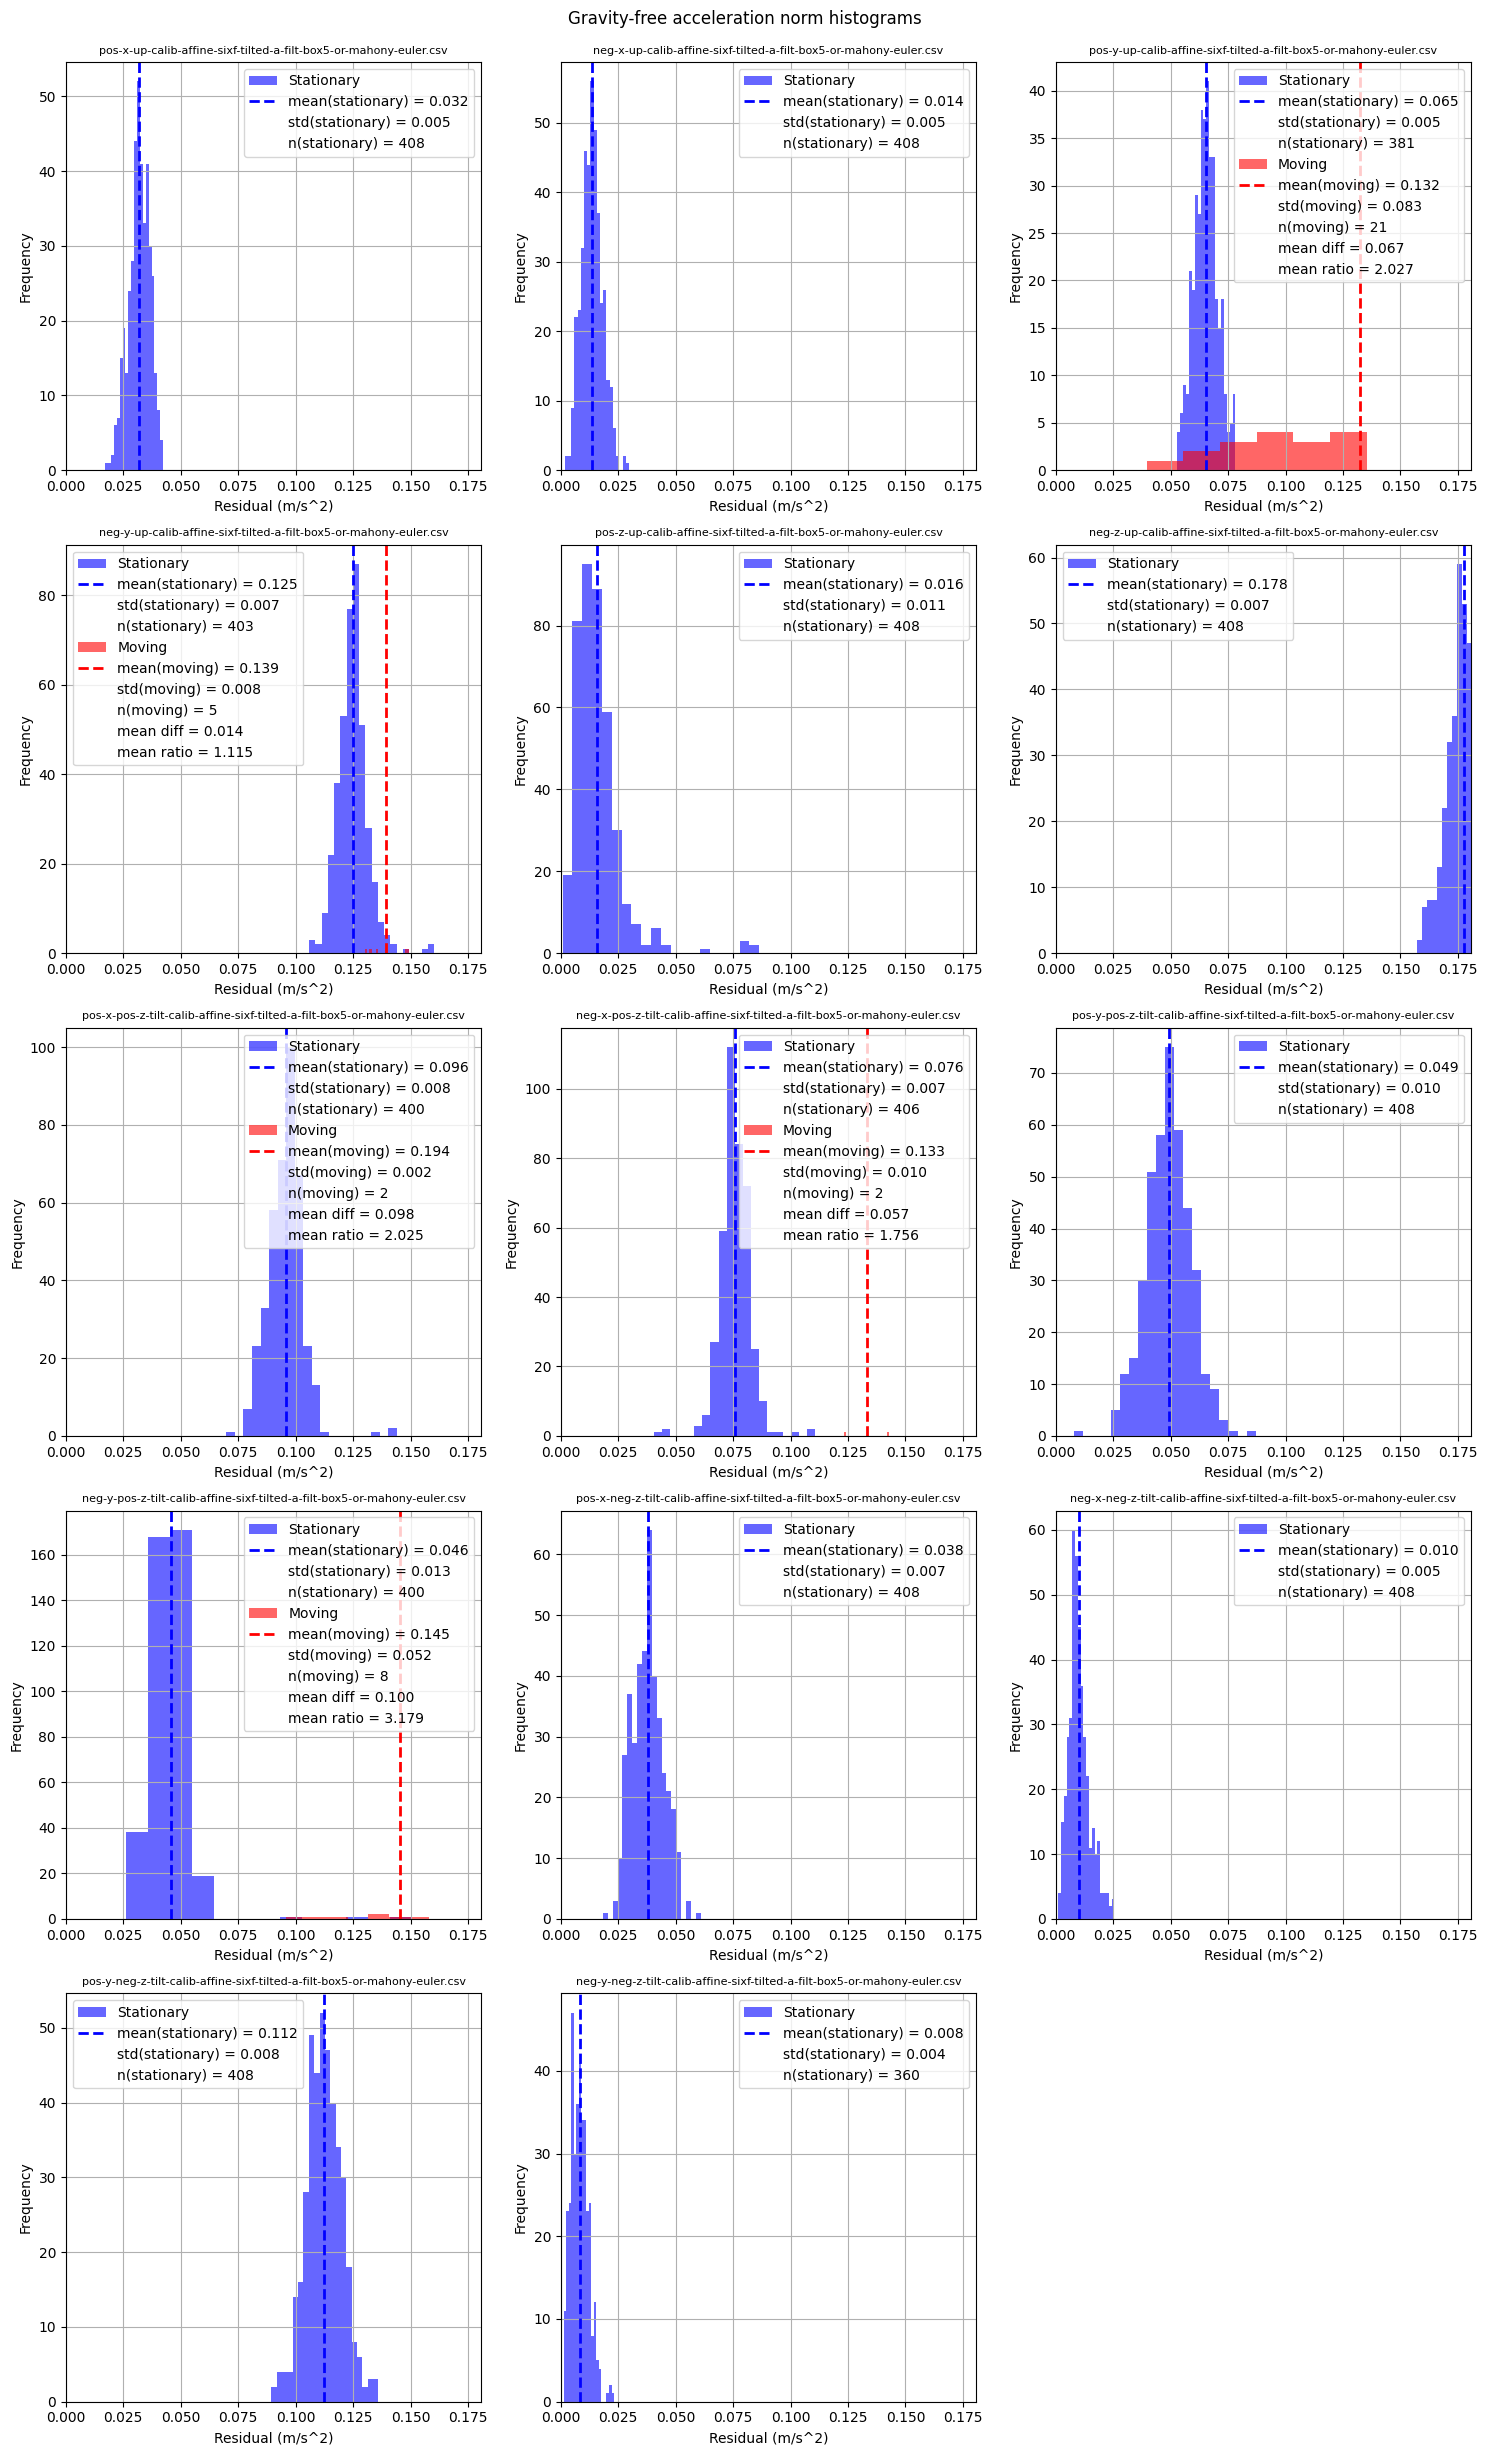

In [57]:
plotGravitySubstractionHistograms(
    mergeDirectoryWithCaptures(gridSearchDirectories[DIRECTORY_IDX], stationaryCaptures)
)

## Simple rotations

As stated in the [protocol](../0-capture/simple-rotations/dataCapture.ipynb) for the capture of simple rotations, the device is rotated around one axis at a time, interleaving brief pauses. When the device is stationary, it should resemble what was seen in the previous section. When it's moving, it should produce another approximately normal distribution to the right of the stationary distribution, but with relatively low mean since movements were performed in a controlled manner.


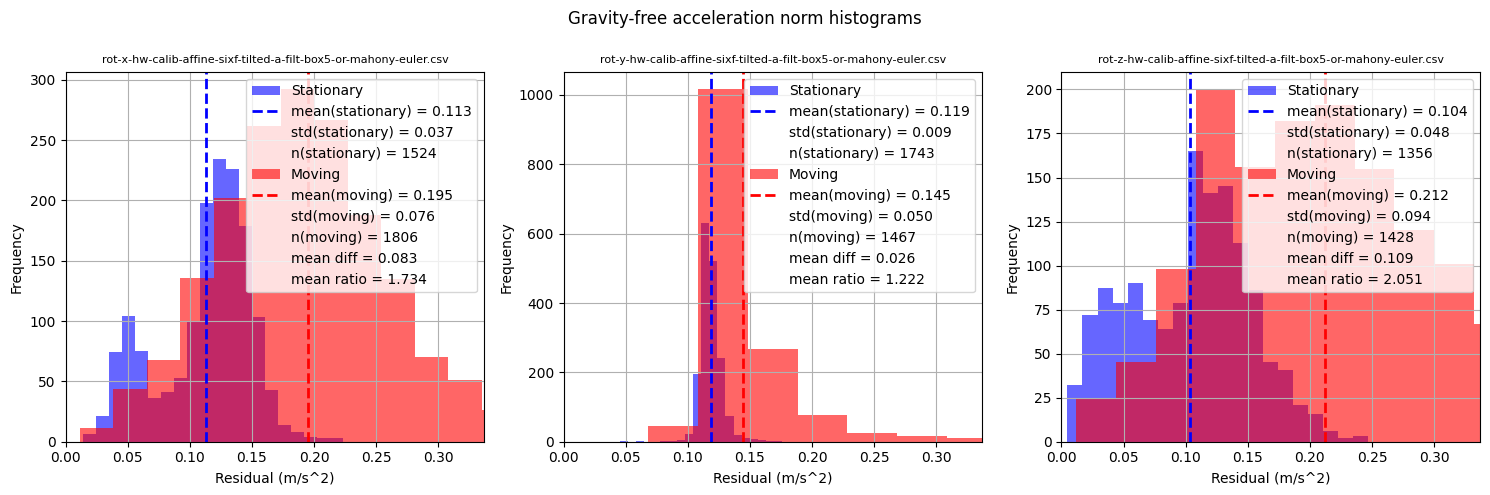

In [58]:
plotGravitySubstractionHistograms(
    mergeDirectoryWithCaptures(
        gridSearchDirectories[DIRECTORY_IDX], simpleRotationsCaptures
    )
)

## Real exercises

Real exercises are more complex, since the device may be rotated around multiple axes at the same time, changes position, and moves fast. 

Finding a suitable pair of $(\alpha_{stationary}, \alpha_{moving})$ values for the complementary filter is needed. A grid search was performed on the [complementary filter notebook](../3-orientation/1-complementaryFilter.ipynb), and here a pair is chosen to:
* Minimize the global mean of stationary acceleration norms: brief stationary intervals should show similar values to those of calibration captures.
* Maximize the difference between the average means of the stationary and moving acceleration norms: to achieve statistical significance, means should be as separated as possible.  
* Maximize the ratio between the average means of the stationary and moving acceleration norms: stationary means should be as small as possible relative to moving means.
* Maximize the correlation between raw acceleration and gravity-free acceleration: the faster the device moves, the greater should the gravity-free acceleration norm be and viceversa.
* Minimize the time lag between raw acceleration and gravity-free acceleration: the gravity-free signal should be as close as possible to the raw signal, but always lagging behind.


In [59]:
def computeMetrics():
    print("Gravity-free norms metrics:")

    minStationaryMeanIdx, minStationaryMean = -1, float("inf")
    maxMeanRatioIdx, maxMeanRatio = -1, float("-inf")
    minLagIdx, minLag = -1, float("inf")
    maxCCIdx, maxCC = -1, float("-inf")
    maxPearsonIdx, maxPearson = -1, float("-inf")
    maxSpearmanIdx, maxSpearman = -1, float("-inf")

    for i, directory in enumerate(gridSearchDirectories):
        stationaryResiduals = []
        movingResiduals = []
        pearsonRs = []
        spearmanRs = []
        lags = []
        corrs = []
        print(f"\tDirectory: {directory} (directoryIdx = {i})")
        for capture in mergeDirectoryWithCaptures(directory, realExerciseCaptures):
            _, a, w, angle = reader.readWithOrientation(capture)
            captureResiduals = np.linalg.norm(subtractGravity(a, angle), axis=1)
            captureStationalityFlags = stationaryChecker.areStationarySamples(a, w)

            captureStationaryResiduals = np.array(
                [
                    residual
                    for residual, isStationary in zip(
                        captureResiduals, captureStationalityFlags
                    )
                    if isStationary
                ]
            )
            stationaryResiduals.append(captureStationaryResiduals)

            captureMovingResiduals = np.array(
                [
                    residual
                    for residual, isStationary in zip(
                        captureResiduals, captureStationalityFlags
                    )
                    if not isStationary
                ]
            )
            movingResiduals.append(captureMovingResiduals)

            captureRawAccelDeviations = np.abs(
                np.linalg.norm(a, axis=1) - stationaryChecker.accelMean
            )
            pearsonRs.append(
                stats.pearsonr(captureRawAccelDeviations, captureResiduals)[0]
            )
            spearmanRs.append(
                stats.spearmanr(captureRawAccelDeviations, captureResiduals)[0]
            )

            captureNormalizedRawAccelDeviations = captureRawAccelDeviations - np.mean(
                captureRawAccelDeviations
            )
            captureNormalizedRawAccelDeviations /= np.std(captureRawAccelDeviations)
            captureNormalizedResiduals = captureResiduals - np.mean(captureResiduals)
            captureNormalizedResiduals /= np.std(captureResiduals)
            captureCorr = signal.correlate(
                captureNormalizedRawAccelDeviations, captureNormalizedResiduals
            )
            lags.append(
                signal.correlation_lags(
                    len(captureNormalizedRawAccelDeviations),
                    len(captureNormalizedResiduals),
                )[np.argmax(captureCorr)]
            )
            corrs.append(np.max(captureCorr))

        stationaryResidualsMean = np.mean(np.concatenate(stationaryResiduals))
        movingResidualsMean = np.mean(np.concatenate(movingResiduals))

        if stationaryResidualsMean < minStationaryMean:
            minStationaryMean = stationaryResidualsMean
            minStationaryMeanIdx = i
        if movingResidualsMean / stationaryResidualsMean > maxMeanRatio:
            maxMeanRatio = movingResidualsMean / stationaryResidualsMean
            maxMeanRatioIdx = i
        if np.mean(pearsonRs) > maxPearson:
            maxPearson = np.mean(pearsonRs)
            maxPearsonIdx = i
        if np.mean(spearmanRs) > maxSpearman:
            maxSpearman = np.mean(spearmanRs)
            maxSpearmanIdx = i
        if np.mean(lags) < minLag:
            minLag = np.mean(lags)
            minLagIdx = i
        if np.mean(corrs) > maxCC:
            maxCC = np.mean(corrs)
            maxCCIdx = i

        print(f"\t\tResiduals:")
        print(f"\t\t\tGlobal stationary mean = {stationaryResidualsMean:.6f}")
        print(f"\t\t\tGlobal moving mean = {movingResidualsMean:.6f}")
        print(
            f"\t\t\tGlobal mean difference = {movingResidualsMean - stationaryResidualsMean:.6f}"
        )
        print(
            f"\t\t\tGlobal mean ratio = {movingResidualsMean / stationaryResidualsMean:.6f}"
        )

        print("\t\tCorrelation (stationary + moving):")
        print(
            f"\t\t\tPearson: \tmin = {np.min(pearsonRs):.6f} (captureIdx = {np.argmin(pearsonRs)}), \tmean = {np.mean(pearsonRs):.6f}, \tmax = {np.max(pearsonRs):.6f} (captureIdx = {np.argmax(pearsonRs)})"
        )
        print(
            f"\t\t\tSpearman: \tmin = {np.min(spearmanRs):.6f} (captureIdx = {np.argmin(spearmanRs)}), \tmean = {np.mean(spearmanRs):.6f}, \tmax = {np.max(spearmanRs):.6f} (captureIdx = {np.argmax(spearmanRs)})"
        )
        print(
            f"\t\t\tLag(samples): \tmin = {np.min(lags):.6f} (captureIdx = {np.argmin(lags)}), \tmean = {np.mean(lags):.6f}, \tmax = {np.max(lags):.6f} (captureIdx = {np.argmax(lags)})"
        )
        print(
            f"\t\t\tMax CC: \tmin = {np.min(corrs):.6f} (captureIdx = {np.argmin(corrs)}), \tmean = {np.mean(corrs):.6f}, \tmax = {np.max(corrs):.6f} (captureIdx = {np.argmax(corrs)})"
        )

        print("\n")

    print(
        f"Global Results:"
        f"\n\t Min stationary mean: {gridSearchDirectories[minStationaryMeanIdx]} (mean = {minStationaryMean:.6f})"
        f"\n\t Max mean ratio: {gridSearchDirectories[maxMeanRatioIdx]} (ratio = {maxMeanRatio:.6f})"
        f"\n\t Max mean pearson: {gridSearchDirectories[maxPearsonIdx]} (pearson = {maxPearson:.6f})"
        f"\n\t Max mean spearman: {gridSearchDirectories[maxSpearmanIdx]} (spearman = {maxSpearman:.6f})"
        f"\n\t Min mean lag: {gridSearchDirectories[minLagIdx]} (lag = {minLag:.6f})"
        f"\n\t Max mean CC: {gridSearchDirectories[maxCCIdx]} (CC = {maxCC:.6f})"
    )


computeMetrics()

Gravity-free norms metrics:
	Directory: ../3-orientation/output/mahony/km=0.250-kp=0.000-ki=0.000 (directoryIdx = 0)
		Residuals:
			Global stationary mean = 0.599193
			Global moving mean = 1.720498
			Global mean difference = 1.121304
			Global mean ratio = 2.871357
		Correlation (stationary + moving):
			Pearson: 	min = 0.568529 (captureIdx = 6), 	mean = 0.880865, 	max = 0.986876 (captureIdx = 3)
			Spearman: 	min = 0.477746 (captureIdx = 6), 	mean = 0.724385, 	max = 0.830854 (captureIdx = 5)
			Lag(samples): 	min = 0.000000 (captureIdx = 0), 	mean = 0.000000, 	max = 0.000000 (captureIdx = 0)
			Max CC: 	min = 545.787989 (captureIdx = 6), 	mean = 699.728810, 	max = 856.814269 (captureIdx = 4)


	Directory: ../3-orientation/output/mahony/km=0.250-kp=0.000-ki=0.010 (directoryIdx = 1)
		Residuals:
			Global stationary mean = 0.473526
			Global moving mean = 1.594888
			Global mean difference = 1.121362
			Global mean ratio = 3.368113
		Correlation (stationary + moving):
			Pearson: 	mi

### Histograms

Choose a suitable set of parameter values from the output above and use it to select a directory with filtered captures to analyze.

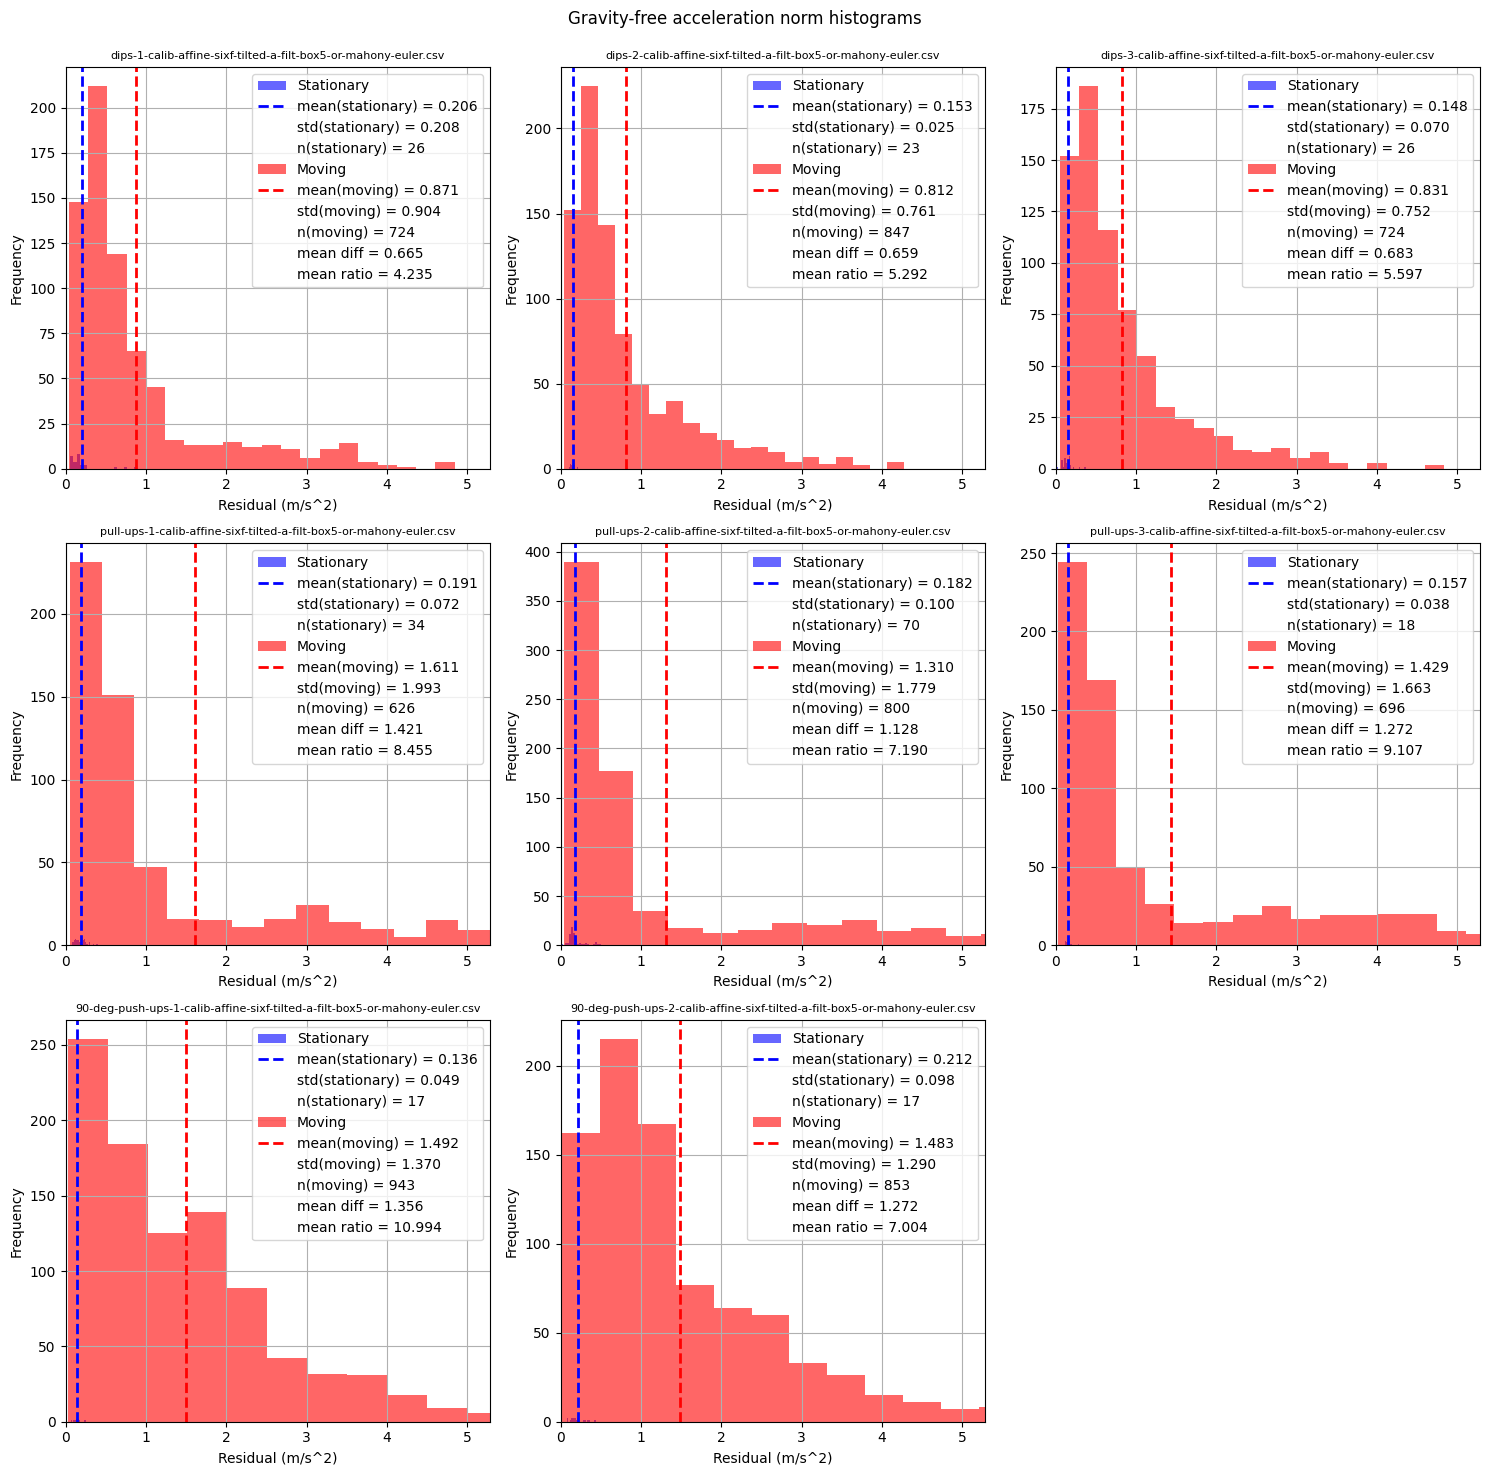

In [60]:
plotGravitySubstractionHistograms(
    mergeDirectoryWithCaptures(
        gridSearchDirectories[DIRECTORY_IDX], realExerciseCaptures
    )
)

### Time series of norms

For captures with high stationary means relative to the others, inspect the time series graph of raw and gravity-free acceleration norms closer. Also compare against angle graphs from the complementary filter notebook. 

General properties:

* When the raw signal is close to $g$, the other one should be close to 0. 
* The norm is strictly non-negative, so when the raw signal exhibits a valley, the gravity-free signal should exhibit a peak. 
* Exercise repetitions should be possible to identify in the gravity-free signal. 
* Amplitudes need not to be the same. 
* Both signals should not have big phase differences. 

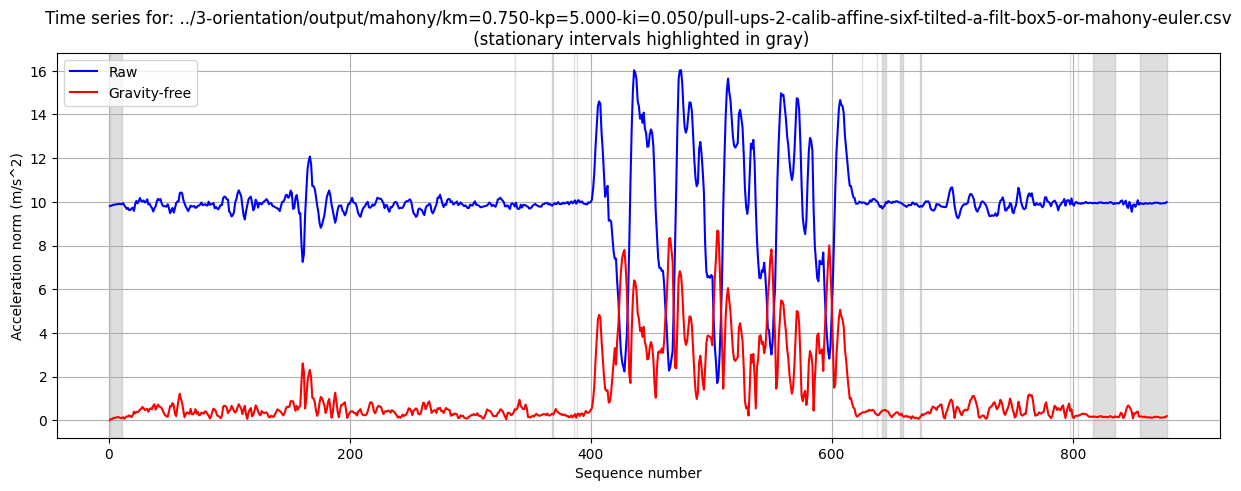

In [61]:
CAPTURE_IDX = 4
chosenCapture = mergeDirectoryWithCaptures(
    gridSearchDirectories[DIRECTORY_IDX], realExerciseCaptures
)[CAPTURE_IDX]
seq, rawAccel, w, angles = reader.readWithOrientation(chosenCapture)
rawAccelNorm = np.linalg.norm(rawAccel, axis=1)
gravityFreeAccelNorm = np.linalg.norm(subtractGravity(rawAccel, angles), axis=1)
stationaryIntervals = stationaryChecker.findStationaryIntervals(seq, rawAccel, w)

fig, axis = plt.subplots(figsize=(15, 5))
axis.plot(seq, rawAccelNorm, label="Raw", color="blue")
axis.plot(seq, gravityFreeAccelNorm, label="Gravity-free", color="red")
axis.set_title(
    f"Time series for: {chosenCapture}\n (stationary intervals highlighted in gray)"
)
axis.set_xlabel("Sequence number")
axis.set_ylabel("Acceleration norm (m/s^2)")
for lower, upper in stationaryIntervals:
    axis.axvspan(lower, upper, color="tab:gray", alpha=0.25, zorder=0)
axis.legend()
axis.grid()
plt.show()

### Scatter plots

Points should follow a functional relationship, either linear or non-linear, instead of being a random cloud of points. Both Pearson and Spearman correlation coefficients are considered. These should be as close to 1 as possible.

Sources:
* https://www.youtube.com/watch?v=k7IctLRiZmo
* https://www.youtube.com/watch?v=XV_W1w4Nwoc
* https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.pearsonr.html
* https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.rankdata.html
* https://en.wikipedia.org/wiki/Ranking
* https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.spearmanr.html#scipy.stats.spearmanr

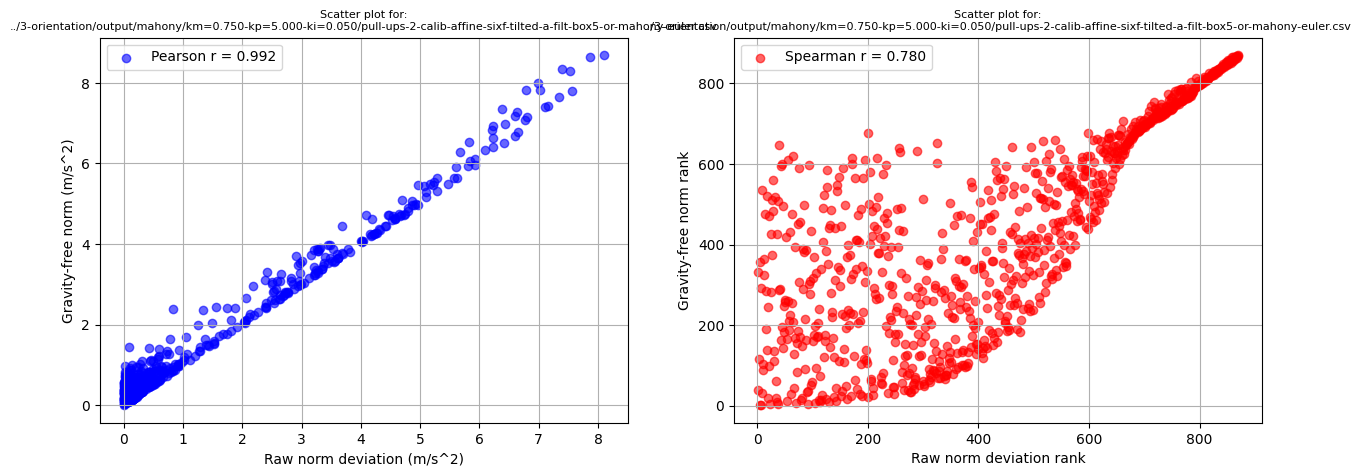

In [62]:
stationaryMask = stationaryChecker.areStationarySamples(rawAccel, w)
rawAccelDeviation = np.abs(rawAccelNorm - stationaryChecker.accelMean)
pearsonR = stats.pearsonr(rawAccelDeviation, gravityFreeAccelNorm)[0]

rawAccelNormRanks = stats.rankdata(rawAccelDeviation, method="average")
gravityFreeAccelNormRanks = stats.rankdata(gravityFreeAccelNorm, method="average")
spearmanR = stats.spearmanr(rawAccelDeviation, gravityFreeAccelNorm)[0]

fig, axis = plt.subplots(1, 2, figsize=(15, 5))
axis[0].set_title(f"Scatter plot for:\n{chosenCapture}", fontsize=8)
axis[0].scatter(
    rawAccelDeviation,
    gravityFreeAccelNorm,
    c="blue",
    alpha=0.6,
)
axis[0].scatter([], [], c="blue", alpha=0.6, label=f"Pearson r = {pearsonR:.3f}")
axis[0].set_xlabel("Raw norm deviation (m/s^2)")
axis[0].set_ylabel("Gravity-free norm (m/s^2)")
axis[0].legend()
axis[0].grid()

axis[1].set_title(f"Scatter plot for:\n{chosenCapture}", fontsize=8)
axis[1].scatter(
    rawAccelNormRanks,
    gravityFreeAccelNormRanks,
    c="red",
    alpha=0.6,
)
axis[1].scatter([], [], c="red", alpha=0.6, label=f"Spearman r = {spearmanR:.3f}")
axis[1].set_xlabel("Raw norm deviation rank")
axis[1].set_ylabel("Gravity-free norm rank")
axis[1].legend()
axis[1].grid()

plt.show()

### Cross correlation

The time displacement or lag of the complementary filter + rotation matrix with respect to the raw signal can be estimated by computing the cross correlation between both signals. Ideally, the lag should be close to 0 but positive. Notice that a negative lag would mean that the gravity-free signal is ahead of the raw signal, which is not physically possible. The lag is given by the index of the maximum value of the cross correlation function. The peak should have relatively high magnitude even after normalization. 

Sources:
- [The scientist and engineer's guide to DSP, Chapter 7](../../docs/misc/The%20Scientist%20and%20Engineers%20Guide%20to%20Digital%20signal%20processing%20-%20Steven%20W.%20Smith.pdf)
- https://www.youtube.com/watch?v=L6YJqhbsuFY
- https://www.youtube.com/watch?v=MQm6ZP1F6ms
- https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.correlate.html
- https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.correlation_lags.html#scipy.signal.correlation_lags


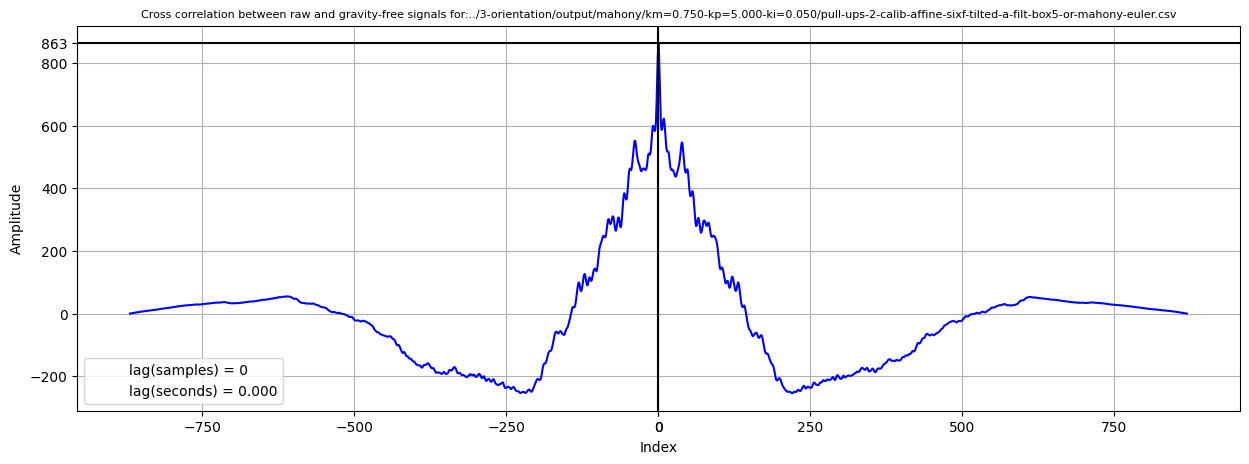

In [63]:
normalizedRawAccelDeviation = rawAccelDeviation - np.mean(rawAccelDeviation)
normalizedRawAccelDeviation /= np.std(normalizedRawAccelDeviation)
normalizedGravityFreeAccelNorm = gravityFreeAccelNorm - np.mean(gravityFreeAccelNorm)
normalizedGravityFreeAccelNorm /= np.std(normalizedGravityFreeAccelNorm)
corr = signal.correlate(normalizedRawAccelDeviation, normalizedGravityFreeAccelNorm)
lags = signal.correlation_lags(
    len(normalizedRawAccelDeviation), len(normalizedGravityFreeAccelNorm)
)
maxCorr = np.max(corr)
lagSamples = lags[np.argmax(corr)]
lagSeconds = lagSamples / SAMPLING_FREQUENCY

fig, axis = plt.subplots(figsize=(15, 5))
axis.set_title(
    f"Cross correlation between raw and gravity-free signals for:{chosenCapture}",
    fontsize=8,
)
axis.plot(lags, corr, color="blue")

axis.axvline(
    lagSamples,
    color="black",
)
axis.axhline(
    maxCorr,
    color="black",
)
xTicks = list(axis.get_xticks())
xTicks.append(lagSamples)
axis.set_xticks(sorted(xTicks))
yTicks = list(axis.get_yticks())
yTicks.append(maxCorr)
axis.set_yticks(sorted(yTicks))

axis.plot([], [], linestyle="", label=f"lag(samples) = {lagSamples}")
axis.plot([], [], linestyle="", label=f"lag(seconds) = {lagSeconds:.3f}")

axis.set_xlabel("Index")
axis.set_ylabel("Amplitude")
axis.legend()
axis.grid()
plt.show()

## Conclusion and export results

For the pair $(\alpha_{stationary}, \alpha_{moving}) = (0.75, 0.95)$ the results are relatively good for the complementary filter:
* Relatively low stationary mean of 0.22 m/s², two orders of magnitude less than $g$. Worst case: 2nd 90 degree push ups capture with 0.3m/s², about 3.06% of $g$.
* Correlation coefficients are relatively high, with Pearson's $r$ around 0.95 and Spearman's $\rho$ around 0.79. Worse case: 2nd dip capture with $r=0.92$ and 2nd pull ups capture with $\rho=0.73$ respectively, still high-ish.
* There's no lag between the raw and gravity-free signals. The max cross-correlation values are high. 
* Visual inspection of graphs look fine for all exercise captures. 
However, it has been seen the remaining error is not good enough for accurate velocity estimation.

In [64]:
FINAL_DIRECTORY_IDX = 0
for capture in mergeDirectoryWithCaptures(
    gridSearchDirectories[FINAL_DIRECTORY_IDX],
    [*stationaryCaptures, *simpleRotationsCaptures, *realExerciseCaptures],
):
    seq, rawAccel, w, angles = reader.readWithOrientation(capture)
    gravityFreeAccel = subtractGravity(rawAccel, angles)
    writer.writeWithOrientation(
        f"./output/{capture.split('/')[-1].split('.')[0]}-g-free-rot-mat.csv",
        seq,
        gravityFreeAccel,
        w,
        angles,
    )